<a href="https://colab.research.google.com/github/gestionymetrologia-lang/ModelosAnaliticosUnicafam202607/blob/main/k_means%2C_Manuel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MODELO K MEANS
Diplomado Analítica de Datos

In [10]:
#  Paso 1. Importar todas las librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# Paso 2.
dataset=pd.read_excel("/content/sample_data/Mall_Customers.xlsx")

In [12]:
# Paso 3. Seleccionar las columnas para determinar el cluster

X=dataset.iloc[:,[3,4]].values

Text(0.5, 0, 'Clústers')

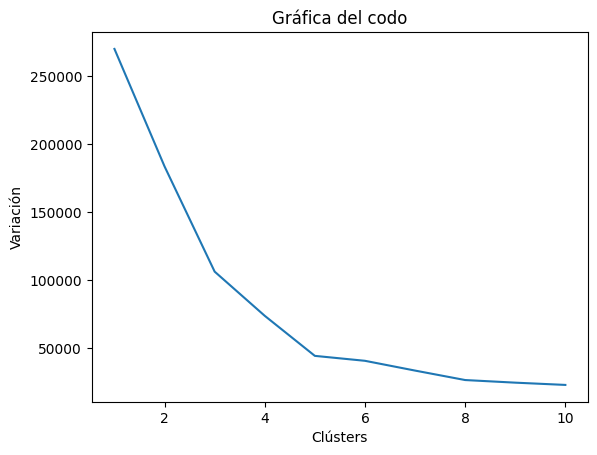

In [13]:
# Paso 4.
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init="k-means++", random_state=42)
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

# Gráfica del codo
plt.plot(range(1,11),wcss)
plt.title("Gráfica del codo")
plt.ylabel("Variación")
plt.xlabel("Clústers")

In [14]:
# Paso 5. Entrenamiento del modelo de clusterización

kmeans=KMeans(n_clusters=5,init="k-means++", random_state=42)
y_kmeans=kmeans.fit_predict(X)


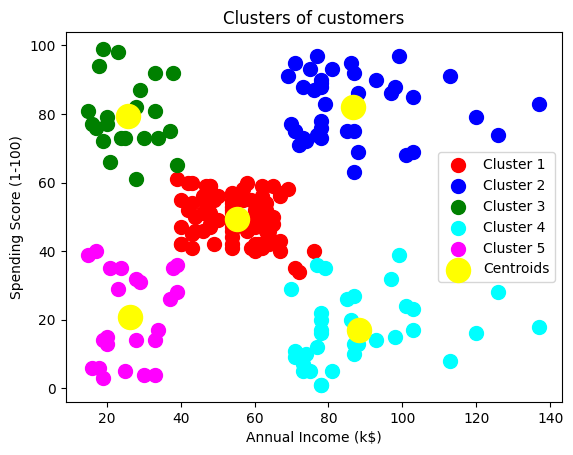

In [15]:
# Paso 6. Visualización de resultados
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


In [16]:
dataset["Cluster"]=y_kmeans
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


In [17]:
dataset.to_csv("Resultados.csv",index=False)